# Model performance map

This notebook runs the strict Friday-to-Friday walk-forward evaluator. Each fit sees only matches with `kickoff < cutoff`; the target window is `[cutoff, cutoff + 7 days)`. Change the configuration cell before running.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from footix.data_io.footballdata import ScrapFootballData
from footix.data_io.utils_scrapper import add_match_id, to_snake_case
from footix.evaluation import (
    BacktestConfig,
    bayesian_spec,
    elo_spec,
    poisson_spec,
    run_backtest,
    uniform_spec,
)
from footix.utils.typing import ProbaResult

In [8]:
#DATA_FILE = Path('../data/FRA Ligue 1_2425.csv')
data_file = ScrapFootballData(competition="FRA Ligue 1", season="2425", path="./data",force_reload=True)
RUN = True
ENABLE_ELO = True
ENABLE_BAYESIAN = True

config = BacktestConfig(
    bankroll=1_000.0,
    max_fraction=0.30,
    fraction_kelly=0.25,
    edge_floor=0.0,
    optimizer_iters=500,
    markets=('1X2', 'U2.5', 'O2.5'),
)

In [9]:
if RUN:
    data = data_file.get_fixtures()
    data.columns = [to_snake_case(column) for column in data.columns]
    data = add_match_id(data)
    n_teams = len(set(data['home_team']) | set(data['away_team']))

    specs = [uniform_spec(), poisson_spec(n_teams=n_teams)]
    if ENABLE_ELO:
        specs.append(
            elo_spec(
                n_teams=n_teams,
                k0=20,
                lambd=0.5,
                sigma=400,
                agnostic_probs=ProbaResult(1 / 3, 1 / 3, 1 / 3),
            )
        )
    if ENABLE_BAYESIAN:
        specs.append(bayesian_spec(n_goals=20, n_teams=n_teams, random_seed=42))

    result = run_backtest(data, specs, config)
    display(result.windows)
else:
    print('Set RUN = True after checking DATA_FILE and the model flags.')

/Users/shaheenacheche/workspace/footix/footix/models/bayesian.py:564: UserWarning: `init='adapt_diag_grad'` is ignored by `nuts_sampler='nutpie'`; the external sampler uses its own initialization.
  trace = pm.sample(**inference_kwargs)
NUTS[nutpie]: [home, intercept, tau_att, raw_atts, tau_def, raw_defs]


Output()

/Users/shaheenacheche/workspace/footix/footix/models/bayesian.py:564: UserWarning: `init='adapt_diag_grad'` is ignored by `nuts_sampler='nutpie'`; the external sampler uses its own initialization.
  trace = pm.sample(**inference_kwargs)
NUTS[nutpie]: [home, intercept, tau_att, raw_atts, tau_def, raw_defs]


Output()

/Users/shaheenacheche/workspace/footix/footix/models/bayesian.py:564: UserWarning: `init='adapt_diag_grad'` is ignored by `nuts_sampler='nutpie'`; the external sampler uses its own initialization.
  trace = pm.sample(**inference_kwargs)
NUTS[nutpie]: [home, intercept, tau_att, raw_atts, tau_def, raw_defs]


...

/Users/shaheenacheche/workspace/footix/footix/models/bayesian.py:564: UserWarning: `init='adapt_diag_grad'` is ignored by `nuts_sampler='nutpie'`; the external sampler uses its own initialization.
  trace = pm.sample(**inference_kwargs)
NUTS[nutpie]: [home, intercept, tau_att, raw_atts, tau_def, raw_defs]


Output()

/Users/shaheenacheche/workspace/footix/footix/models/bayesian.py:564: UserWarning: `init='adapt_diag_grad'` is ignored by `nuts_sampler='nutpie'`; the external sampler uses its own initialization.
  trace = pm.sample(**inference_kwargs)
NUTS[nutpie]: [home, intercept, tau_att, raw_atts, tau_def, raw_defs]


Output()

,model,cutoff,window_end,train_matches,target_matches,bankroll_before,final_window,status,reason,predicted_rows,prediction_errors,bets,total_stake,profit,bankroll_after
0,uniform,2024-08-16,2024-08-23,0,9,1000.00,False,ok,None,27.0,0.0,0.0,0.0,0.00,1000.00
1,poisson,2024-08-16,2024-08-23,0,9,1000.00,False,ineligible,no_training_data,NaN,NaN,NaN,NaN,NaN,NaN
2,elo,2024-08-16,2024-08-23,0,9,1000.00,False,ineligible,no_training_data,NaN,NaN,NaN,NaN,NaN,NaN
3,bayesian,2024-08-16,2024-08-23,0,9,1000.00,False,ineligible,no_training_data,NaN,NaN,NaN,NaN,NaN,NaN
4,uniform,2024-08-23,2024-08-30,9,9,1000.00,False,ok,None,27.0,0.0,0.0,0.0,0.00,1000.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,bayesian,2025-05-09,2025-05-16,288,9,1173.92,False,ok,None,63.0,0.0,8.0,208.0,184.86,1358.78
132,uniform,2025-05-16,2025-05-23,297,9,1000.00,True,ok,None,27.0,0.0,0.0,0.0,0.00,1000.00
133,poisson,2025-05-16,2025-05-23,297,9,732.76,True,ok,None,63.0,0.0,7.0,219.0,-55.75,677.01
134,elo,2025-05-16,2025-05-23,297,9,1023.10,True,ok,None,27.0,0.0,9.0,269.0,-269.00,754.10


rps  log_loss     brier  accuracy
model    market                                        
bayesian 1X2     0.210561  0.985879  0.195275  0.545455
         O2.5    0.261075  0.719287  0.261075  0.569024
         U2.5    0.261075  0.719287  0.261075  0.569024
elo      1X2     0.222889  1.034956  0.206697  0.531250
poisson  1X2     0.219908  1.044510  0.201418  0.541667
         O2.5    0.266536  0.765502  0.266536  0.552083
         U2.5    0.266536  0.765502  0.266536  0.552083
uniform  1X2     0.244009  1.098612  0.222222  0.467320

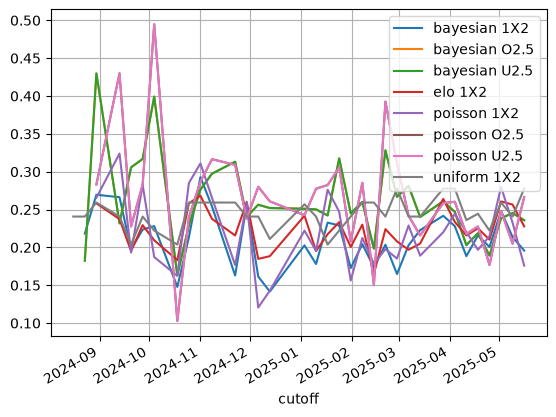

,model,cutoff,window_end,match_id,market,selection,odds,probability,edge,edge_std,stake,won,profit
0,bayesian,2024-08-23,2024-08-30,Paris SG - Montpellier - 2024-08-23,1X2,A,10.00,0.260142,1.601421,0.274722,26.0,False,-26.00
1,bayesian,2024-08-23,2024-08-30,Lyon - Monaco - 2024-08-24,U2.5,U2.5,2.63,0.663617,0.745311,0.315871,26.0,True,42.38
2,bayesian,2024-08-23,2024-08-30,Lille - Angers - 2024-08-24,1X2,A,9.00,0.238404,1.145634,0.252781,26.0,False,-26.00
3,bayesian,2024-08-23,2024-08-30,St Etienne - Le Havre - 2024-08-24,1X2,A,3.50,0.318524,0.114835,0.283049,26.0,True,65.00
4,bayesian,2024-08-23,2024-08-30,Lens - Brest - 2024-08-25,O2.5,O2.5,2.02,0.510527,0.031265,0.325691,26.0,False,-26.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,bayesian,2025-05-16,2025-05-23,Nantes - Montpellier - 2025-05-17,U2.5,U2.5,2.10,0.636483,0.336613,0.119174,26.0,False,-26.00
854,bayesian,2025-05-16,2025-05-23,Nice - Brest - 2025-05-17,1X2,A,6.50,0.214180,0.392169,0.083913,26.0,False,-26.00
855,bayesian,2025-05-16,2025-05-23,Paris SG - Auxerre - 2025-05-17,1X2,A,13.00,0.149663,0.945624,0.072306,26.0,False,-26.00
856,bayesian,2025-05-16,2025-05-23,St Etienne - Toulouse - 2025-05-17,1X2,A,3.25,0.508072,0.651235,0.114626,26.0,True,58.50


,profit,total_stake,bankroll_after
model,,,
bayesian,-71.50,234.0,1287.28
elo,-269.00,269.0,754.10
poisson,-55.75,219.0,677.01
uniform,0.00,0.0,1000.00


In [10]:
if RUN and not result.predictions.empty:
    summary = (
        result.predictions.groupby(['model', 'market'])[['rps', 'log_loss', 'brier', 'accuracy']]
        .mean()
        .sort_index()
    )
    display(summary)

    for (model, market), values in result.predictions.groupby(['model', 'market']):
        values.groupby('cutoff')['rps'].mean().plot(label=f'{model} {market}')
    plt.legend()
    plt.grid()
    plt.show()

    if not result.bets.empty:
        display(result.bets)
        display(result.windows.groupby('model')[['profit', 'total_stake', 'bankroll_after']].last())

    result.windows.to_csv('model_performance_windows.csv', index=False)
    result.predictions.to_csv('model_performance_predictions.csv', index=False)
    result.bets.to_csv('model_performance_bets.csv', index=False)